In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1D Conv


In [2]:
def conv1d_zeropad(l, h):
    """l: signal, h: conv kernel"""
    assert len(l.shape) == 1
    assert len(h.shape) == 1

    out = np.zeros(l.shape[0] + h.shape[0] - 1)
    for n in range(out.shape[0]):
        out[n] = 0
        for k in range(l.shape[0]):
            hidx = n - k
            if hidx >= 0 and hidx < h.shape[0]:
                out[n] += h[hidx] * l[k]
    return out


l = np.array([1, 2, 3, 4])
h = np.array([-1, -2, -3])
conv1d_zeropad(l, h)

array([ -1.,  -4., -10., -16., -17., -12.])

In [3]:
def crosscorr1d_zeropad(l, h):
    assert len(l.shape) == 1
    assert len(h.shape) == 1

    out = np.zeros(l.shape[0])  # TODO: boundary
    for n in range(out.shape[0]):
        out[n] = 0
        for k in range(h.shape[0]):
            lidx = n + k
            if lidx >= 0 and lidx < l.shape[0]:
                out[n] += h[k] * l[lidx]
    return out


l = np.array([1, 2, 3, 4])
h = np.array([-1, -2, -3])
crosscorr1d_zeropad(l, h)

array([-14., -20., -11.,  -4.])

# 2D


In [4]:
def conv2d_zeropad(l, h):
    assert len(l.shape) == 2
    assert len(h.shape) == 2

    out = np.zeros(shape=(l.shape[0] + h.shape[0] - 1, l.shape[1] + h.shape[1] - 1))
    for n in range(out.shape[0]):
        for m in range(out.shape[1]):
            out[n, m] = 0
            for k in range(l.shape[0]):
                for j in range(l.shape[1]):
                    hidx_n = n - k
                    hidx_m = m - j
                    if (
                        hidx_n >= 0
                        and hidx_n < h.shape[0]
                        and hidx_m >= 0
                        and hidx_m < h.shape[1]
                    ):
                        out[n, m] += h[hidx_n, hidx_m] * l[k, j]
    return out


def crosscorr2d_zeropad(l, h):
    assert len(l.shape) == 2
    assert len(h.shape) == 2

    out = np.zeros(shape=(l.shape[0], l.shape[1]))  # TODO: boundary?
    for n in range(out.shape[0]):
        for m in range(out.shape[1]):
            out[n, m] = 0
            for k in range(h.shape[0]):
                for j in range(h.shape[1]):
                    lidx_n = n + k
                    lidx_m = m + j
                    if (
                        lidx_n >= 0
                        and lidx_n < l.shape[0]
                        and lidx_m >= 0
                        and lidx_m < l.shape[1]
                    ):
                        out[n, m] += h[k, j] * l[lidx_n, lidx_m]
    return out

# Template Matching

[visionbook](https://visionbook.mit.edu/linear_image_filtering.html)

We can use cross-correlation to "match templates". This is a very simple and naive object detector. It's shift-invariant, but it doesn't deal with scale, rotation, illumination or any non-trivial intra-class variation.

Notice that for matching we need _cross-correlation_, not _convolution_.

We use a simple triangle as a pattern:


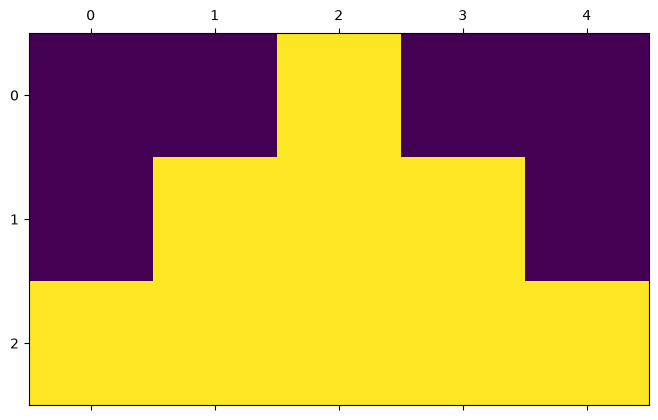

In [5]:
kernel = np.array([[0, 0, 1, 0, 0], [0, 1, 1, 1, 0], [1, 1, 1, 1, 1]])
plt.matshow(kernel)
plt.show()

Now, we create some images that contain the pattern and it's flipped version.


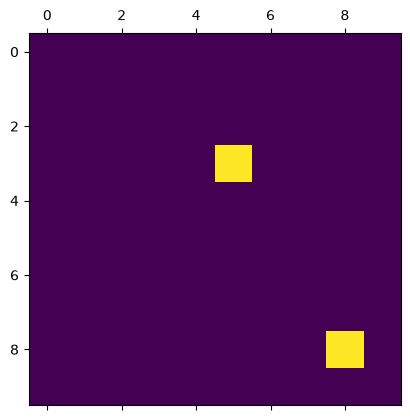

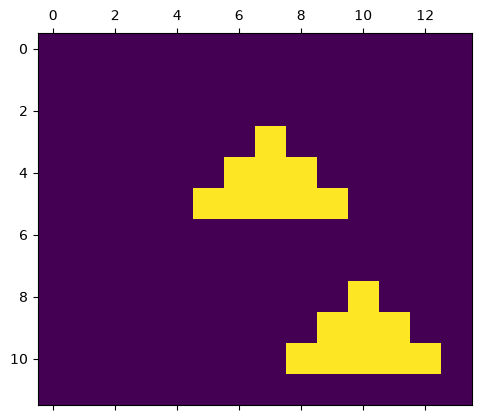

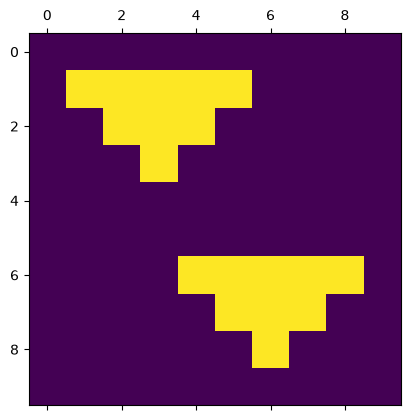

In [6]:
image = np.zeros(shape=(10, 10))
image[3, 5] = 1
image[8, 8] = 1
plt.matshow(image)

out = conv2d_zeropad(image, kernel)
plt.matshow(out)
plt.show()

out = crosscorr2d_zeropad(image, kernel)
plt.matshow(out)
plt.show()

How can we detect this pattern in an image? we slide the pattern in every possible position and we compute the similarity between the local patch of the image and the pattern. Cross-correlation does what we want.


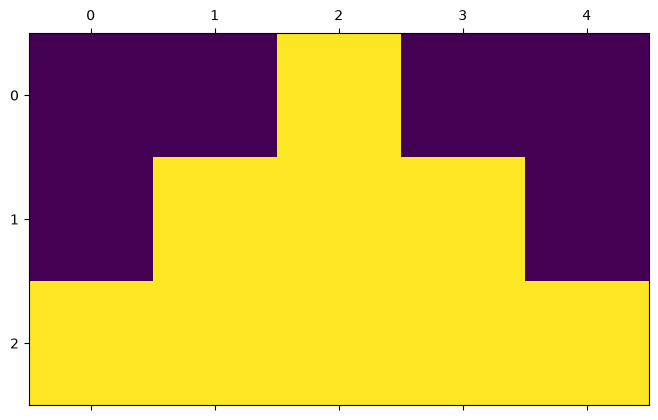

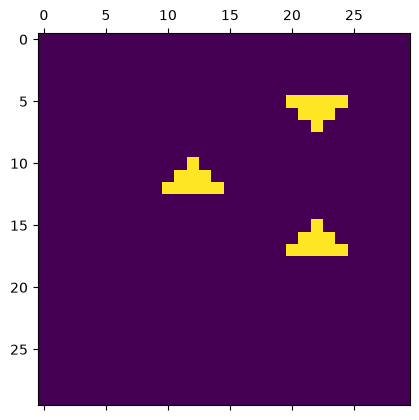

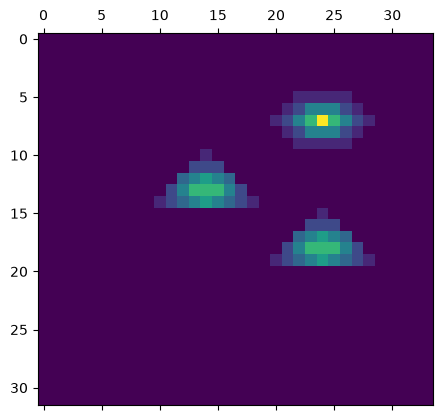

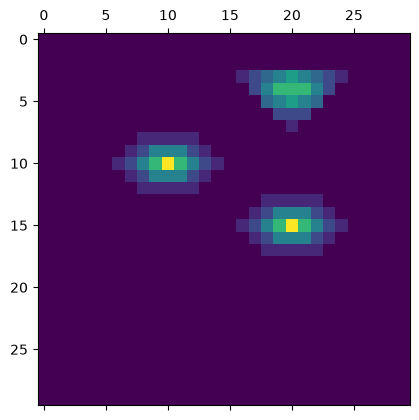

In [7]:
kernel = np.array([[0, 0, 1, 0, 0], [0, 1, 1, 1, 0], [1, 1, 1, 1, 1]])
plt.matshow(kernel)

image = np.zeros(shape=(30, 30))
image[10:13, 10:15] = kernel
image[15:18, 20:25] = kernel

image[5:8, 20:25] = kernel[::-1]

plt.matshow(image)

out = conv2d_zeropad(image, kernel)
plt.matshow(out)

out = crosscorr2d_zeropad(image, kernel)
plt.matshow(out)


There is one final issue we have to address. Cross-correlation is not normalized, so brighter patterns (higher pixel values) will always have higher correlations. To fix this issue, we normalize the template and divide the cross-correlation results by the local standard deviation (as in eq. in the book).


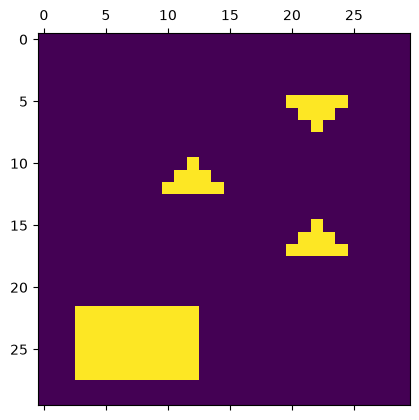

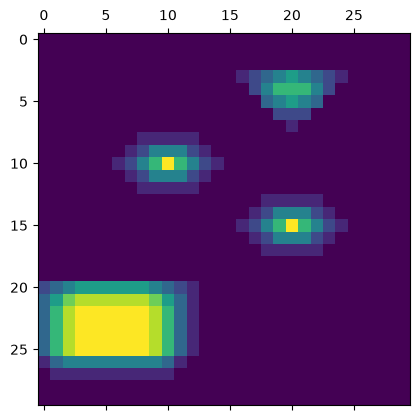

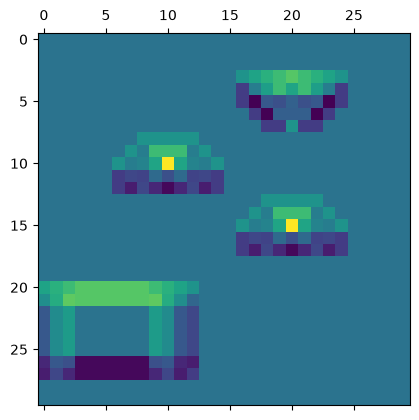

In [8]:
def template_matching(l, h):
    assert len(l.shape) == 2
    assert len(h.shape) == 2
    eps = 10 ** (-5)  # small value for stable non-zero divisions

    h_mu = h.mean()
    h_std = h.std() + eps
    h = (h - h_mu) / h_std  # normalized kernel -> template

    out = np.zeros(shape=(l.shape[0], l.shape[1]))  # TODO: boundary?
    for n in range(out.shape[0]):
        for m in range(out.shape[1]):
            out[n, m] = 0
            for k in range(h.shape[0]):
                for j in range(h.shape[1]):
                    lidx_n = n + k
                    lidx_m = m + j
                    if (
                        lidx_n >= 0
                        and lidx_n < l.shape[0]
                        and lidx_m >= 0
                        and lidx_m < l.shape[1]
                    ):
                        out[n, m] += h[k, j] * l[lidx_n, lidx_m]
            # normalize
            out[n, m] = out[n, m] / (
                l[n : n + h.shape[0], m : m + h.shape[1]].std() + eps
            )
    return out


kernel = np.array([[0, 0, 1, 0, 0], [0, 1, 1, 1, 0], [1, 1, 1, 1, 1]])
# plt.matshow(kernel)

image = np.zeros(shape=(30, 30))
image[10:13, 10:15] = kernel
image[15:18, 20:25] = kernel
image[22:28, 3:13] = 1

image[5:8, 20:25] = kernel[::-1]
plt.matshow(image)

out = crosscorr2d_zeropad(image, kernel)
plt.matshow(out)

out = template_matching(image, kernel)
plt.matshow(out)

# Exercises

- try to implement different padding and boundary conditions (e.g. circular padding)
- try template matching with different images
  - can you recognize characters from an image with text? how robust is this method?
    - example: write some text in word and screenshot it, save an image, and save a template for a single character
    - try different fonts and see if it's possible to recognize bold characters with non-bold templates or similar hard settings (e.g. ambiguous fonts and characters)
- try to detect the birds in [Fig 15.5](https://visionbook.mit.edu/linear_image_filtering.html).
  - Download the image and create a template by cropping a single bird manually
  - hint: at the original resolution, the detector may be a bit noisy. Try to resize the image (e.g. using [zoom](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.zoom.html)) to a smaller resolution. At lower solutions the birds will become simpler templates
